In [2]:
import pandas as pd

In [54]:
food_data = pd.read_csv("food_coded.csv")
new_rows = pd.DataFrame({
    "income": [1],        # un low income, un high income
    "veggies_day": [3]    # neutral
})
food_data = pd.concat([food_data, new_rows], ignore_index=True)
food_data[food_data["employment"]==1.0]["employment"] = 2.0
food_data.to_csv("food_coded_2.csv", index=False)

/var/folders/6f/0n_tx1_52_j72w8klppsd8qc0000gn/T/ipykernel_19847/983396571.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  food_data[food_data["employment"]==1.0]["employment"] = 2.0


In [50]:
food_data.head()

,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2.0,1.0,430.0,NaN,315.0,1.0,none,we dont have comfort,9.0,...,1.0,1.0,1.0,1165.0,345.0,car racing,5,1.0,1315.0,187
1,3.654,1.0,1.0,610.0,3.0,420.0,2.0,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2.0,725.0,690.0,Basketball,4,2.0,900.0,155
2,3.3,1.0,1.0,720.0,4.0,420.0,2.0,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5.0,1165.0,500.0,none,5,1.0,900.0,I'm not answering this.
3,3.2,1.0,1.0,430.0,3.0,420.0,2.0,"Pizza, Mac and cheese, ice cream",Boredom,2.0,...,1.0,2.0,5.0,725.0,690.0,NaN,3,1.0,1315.0,"Not sure, 240"
4,3.5,1.0,1.0,720.0,2.0,420.0,2.0,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,...,1.0,1.0,4.0,940.0,500.0,Softball,4,2.0,760.0,190


In [51]:
food_data["comfort_food_reasons_coded"].value_counts()

comfort_food_reasons_coded
2.0    49
1.0    22
3.0    18
9.0     5
5.0     4
4.0     3
7.0     3
6.0     1
8.0     1
Name: count, dtype: int64

## Chart one comfort food

In [40]:
mapping = {1: "stress",
           2: "boredom",
           3: "depression/sadness",
           4: "hunger",
           5: "laziness",
           6: "cold weather",
           7: "happiness",
           8: "watching tv",
           9: "none"}

comfort_food_reasons = food_data["comfort_food_reasons_coded"].map(mapping)


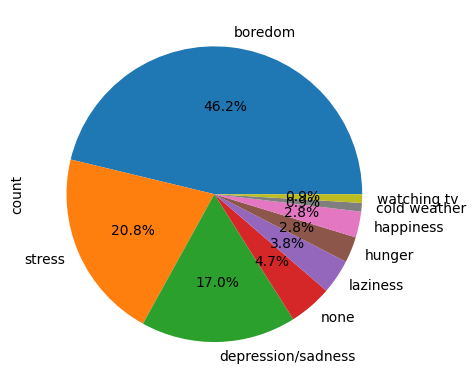

In [41]:
import matplotlib.pyplot as plt
comfort_food_reasons.value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.show()

CHart 2 Income vs vegetables
 

In [42]:
import pandas as pd
import altair as alt

# mappings
mapping_income = {
    1: "less than $15,000",
    2: "$15,001 to $30,000",
    3: "$30,001 to $50,000",
    4: "$50,001 to $70,000",
    5: "$70,001 to $100,000",
    6: "higher than $100,000"
}

mapping_veg = {
    1: "very unlikely",
    2: "unlikely",
    3: "neutral",
    4: "likely",
    5: "very likely"
}

data_short = food_data[["income", "veggies_day"]].copy()

data_short["income"] = data_short["income"].map(mapping_income)
data_short["veggies_day"] = data_short["veggies_day"].map(mapping_veg)

# regrouper very likely / very unlikely
data_short.loc[data_short["veggies_day"] == "very likely", "veggies_day"] = "likely"
data_short.loc[data_short["veggies_day"] == "very unlikely", "veggies_day"] = "unlikely"


# --- regroupement income ---
def income_group(x):
    if x == "less than $15,000":
        return "No income"
    elif x in ["$15,001 to $30,000", "$30,001 to $50,000"]:
        return "Low income (less than $50,000 a year)"
    else:
        return "High income"

data_short["income_group"] = data_short["income"].apply(income_group)


# --- calcul pourcentage ---
grouped = (
    data_short
    .groupby(["income_group", "veggies_day"])
    .size()
    .reset_index(name="count")
)

grouped["percentage"] = grouped.groupby("income_group")["count"].transform(lambda x: x / x.sum() * 100)


# --- graphique Altair ---
chart = alt.Chart(grouped).mark_bar().encode(
    x=alt.X("income_group:N", title="Income category",sort=["No income", "Low income (less than $50,000 a year)", "High income"],axis=alt.Axis(labelAngle=0)),
    y=alt.Y("percentage:Q", title="Percentage of students"),
    xOffset="veggies_day:N",
    color=alt.Color("veggies_day:N", title="Vegetable consumption likelihood",sort=["unlikely", "neutral", "likely"]),
    tooltip=["income_group", "veggies_day", "percentage"],
).properties(
    title="Income vs Likelihood of Eating Vegetables Daily",
    width=600,
)

chart

alt.Chart(...)

chart 3 - cook

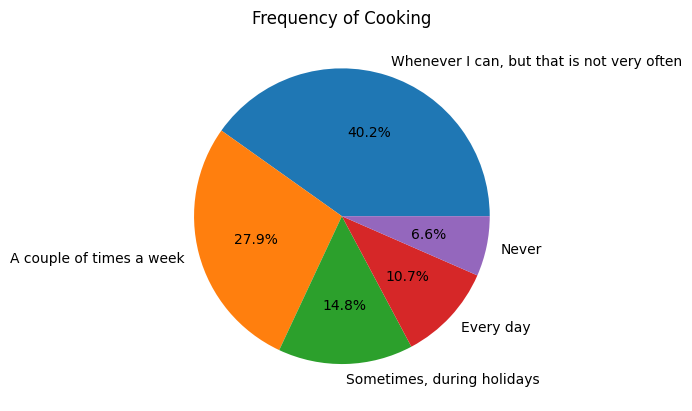

In [30]:


cook_mapping = {1: "Every day",
                2: "A couple of times a week",
                3: "Whenever I can, but that is not very often",
                4: "Sometimes, during holidays",
                5: "Never"}

data_cook = food_data["cook"]
data_cook = data_cook.map(cook_mapping)
data_cook.value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Frequency of Cooking")
plt.show()

chart 4 Eating changes since college

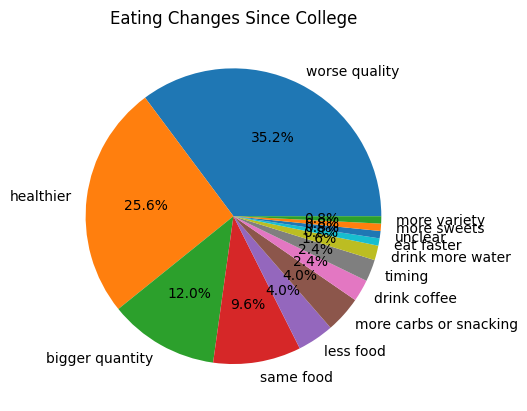

In [34]:

change_mapping = {1: "eat faster",
                  2: "bigger quantity",
                  3: "worse quality",
                  4: "same food",
                  5: "healthier",
                  6: "unclear",
                  7: "drink coffee",
                  8: "less food",
                  9: "more sweets",
                  10: "timing",
                  11: "more carbs or snacking",
                  12: "drink more water",
                  13: "more variety"}

data_change = food_data["eating_changes_coded1"]
data_change = data_change.map(change_mapping)
data_change.value_counts().plot(kind="pie", autopct="%1.1f%%", labeldistance=1.1)
plt.title("Eating Changes Since College")
plt.xticks(rotation=45)
plt.show()

Chart 5 Eating out frequency vs on out of campus

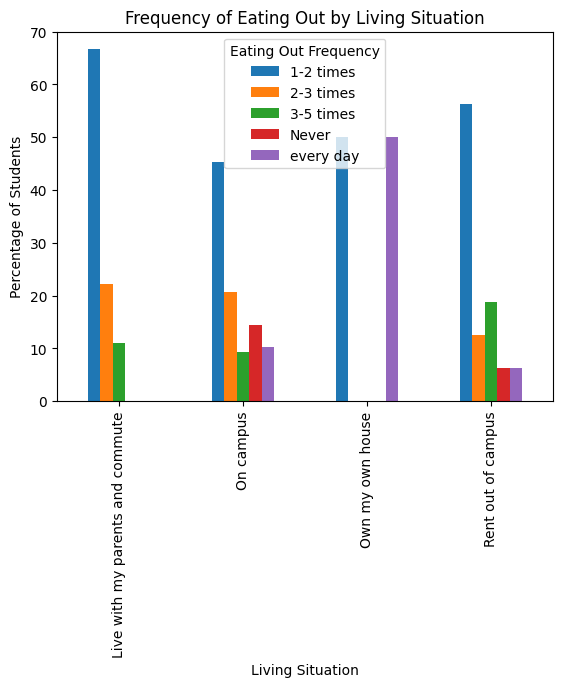

In [37]:

eat_out_mapping = {1: "Never",
                   2: "1-2 times",
                   3: "2-3 times",
                   4: "3-5 times",
                   5: "every day"}

on_campus_mapping = {1: "On campus",
                     2: "Rent out of campus",
                     3: "Live with my parents and commute",
                     4: "Own my own house"}

data_eat_out = food_data[["eating_out","on_off_campus"]]
data_eat_out["eating_out"] = data_eat_out["eating_out"].map(eat_out_mapping)
data_eat_out["on_off_campus"] = data_eat_out["on_off_campus"].map(on_campus_mapping)
grouped_percent_eat_out = pd.crosstab(data_eat_out["on_off_campus"],
    data_eat_out["eating_out"],
    normalize="index"   # normalise par eating out frequency
) * 100
grouped_percent_eat_out.plot(kind="bar")
plt.xlabel("Living Situation")
plt.ylabel("Percentage of Students")
plt.legend(title="Eating Out Frequency")
plt.title("Frequency of Eating Out by Living Situation")
plt.show()

In [52]:
import altair as alt
food_data = pd.read_csv("food_coded_2.csv")
chart = alt.Chart(food_data).mark_circle(size=70, opacity=0.6).encode(
    
    x=alt.X(
        "healthy_feeling:Q",
        title="Perceived healthiness of diet (1 = very unhealthy, 10 = very healthy)",
        scale=alt.Scale(domain=[1,10])
    ),

    y=alt.Y(
        "employment:N",
        title="Employment status"
    ),

    color=alt.Color(
        "employment:N",
        legend=None
    ),

    tooltip=[
        "employment",
        "healthy_feeling"
    ]

).properties(
    title="Perceived Diet Healthiness by Employment Status"
)
chart


alt.Chart(...)

In [56]:
food_data["healthy_feeling"].value_counts()

healthy_feeling
8.0     17
7.0     16
5.0     15
3.0     15
4.0     13
2.0     12
6.0     12
9.0     12
1.0      8
10.0     5
Name: count, dtype: int64

In [65]:
food_data=pd.read_csv("food_coded_2.csv")
food_data["employment_status"] = food_data["employment"].map({
    1: "Part-time employed",
    2: "Part-time employed",
    3: "Unemployed"
})


def healthy_group(x):
    if x <= 4:
        return "Unhealthy"
    elif x <= 7:
        return "Moderately healthy"
    else:
        return "Healthy"


food_data["healthy_group"] = food_data["healthy_feeling"].apply(healthy_group)
print(food_data[["healthy_feeling", "healthy_group"]].head())
health_dist = (
    food_data.groupby(["employment_status", "healthy_group"])
    .size()
    .reset_index(name="count")
)

health_dist["percentage"] = (
    health_dist.groupby("employment_status")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

import altair as alt

chart = alt.Chart(health_dist).mark_bar(size=30).encode(

    x=alt.X(
        "employment_status:N",
        title="Employment status",
        axis=alt.Axis(labelAngle=0)
    ),

    y=alt.Y(
        "percentage:Q",
        title="Percentage of students"
    ),

    xOffset="healthy_group:N",

    color=alt.Color(
        "healthy_group:N",
        title="Perceived diet healthiness",
        sort=["Unhealthy", "Moderately healthy", "Healthy"]
    )

).properties(
    title="Perceived Diet Healthiness by Employment Status",
    width=300
)

chart

   healthy_feeling       healthy_group
0              2.0           Unhealthy
1              5.0  Moderately healthy
2              6.0  Moderately healthy
3              7.0  Moderately healthy
4              6.0  Moderately healthy


alt.Chart(...)

In [61]:
food_data["employment"].value_counts()

employment
2.0    60
3.0    54
1.0     2
Name: count, dtype: int64

preprocess

In [71]:
import pandas as pd

# --- 1. Charger le dataset ---
df = pd.read_csv("food_coded.csv")

# --- 2. Mapper income et veggies_day ---
mapping_income = {
    1: "less than $15,000",
    2: "$15,001 to $30,000",
    3: "$30,001 to $50,000",
    4: "$50,001 to $70,000",
    5: "$70,001 to $100,000",
    6: "higher than $100,000"
}

mapping_veg = {
    1: "very unlikely",
    2: "unlikely",
    3: "neutral",
    4: "likely",
    5: "very likely"
}

df["income"] = df["income"].map(mapping_income)
df["veggies_day"] = df["veggies_day"].map(mapping_veg)

# Fusionner very likely / very unlikely
df.loc[df["veggies_day"] == "very likely", "veggies_day"] = "likely"
df.loc[df["veggies_day"] == "very unlikely", "veggies_day"] = "unlikely"

# --- 3. Créer groupes d'income simplifiés ---
def income_group(x):
    if x == "less than $15,000":
        return "No income"
    elif x in ["$15,001 to $30,000", "$30,001 to $50,000"]:
        return "Low income"
    else:
        return "High income"

df["Income Group"] = df["income"].apply(income_group)

# --- 4. Simplifier employment ---
df["Employment Status"] = df["employment"].map({
    1: "Part-time employed",
    2: "Part-time employed",
    3: "Unemployed"
})

# --- 5. Grouper healthy_feeling ---
def healthy_group(x):
    if x <= 4:
        return "Unhealthy"
    elif x <= 7:
        return "Moderately healthy"
    else:
        return "Healthy"

df["Healthy Feeling Group"] = df["healthy_feeling"].apply(healthy_group)

# --- 6. Renommer colonnes principales pour le MVP ---
df.rename(columns={
    "veggies_day": "Vegetable Eating Likelihood",
    "healthy_feeling": "Healthy Feeling Score",
    "income": "Income",
}, inplace=True)

# --- 7. Vérification ---
print(df[["Income", "Income Group", "Vegetable Eating Likelihood", 
          "Employment Status", "Healthy Feeling Score", "Healthy Feeling Group"]].head())

# --- 8. Sauvegarder le DataFrame prétraité ---
df.to_csv("food_preprocessed.csv", index=False)
print("✅ Preprocessed dataframe saved as 'food_preprocessed.csv'")

                 Income Income Group Vegetable Eating Likelihood  \
0   $70,001 to $100,000  High income                      likely   
1    $50,001 to $70,000  High income                      likely   
2  higher than $100,000  High income                      likely   
3  higher than $100,000  High income                     neutral   
4  higher than $100,000  High income                      likely   

    Employment Status  Healthy Feeling Score Healthy Feeling Group  
0          Unemployed                      2             Unhealthy  
1  Part-time employed                      5    Moderately healthy  
2          Unemployed                      6    Moderately healthy  
3          Unemployed                      7    Moderately healthy  
4  Part-time employed                      6    Moderately healthy  
✅ Preprocessed dataframe saved as 'food_preprocessed.csv'


In [72]:
import pandas as pd

df = pd.read_csv("food_preprocessed.csv")

# --- Mapper cook ---
cook_map = {
    1: "Every day",
    2: "A couple times a week",
    3: "Whenever I can, but not often",
    4: "Little help during holidays",
    5: "Never"
}
df["Cook Frequency"] = df["cook"].map(cook_map)

# --- Mapper eating_out ---
eat_out_map = {
    1: "Never",
    2: "1-2 times/week",
    3: "2-3 times/week",
    4: "3-5 times/week",
    5: "Every day"
}
df["Eating Out Frequency"] = df["eating_out"].map(eat_out_map)

# --- Regrouper on_off_campus ---
campus_map = {
    1: "On campus",
    2: "Rent out",
    3: "With parents",
    4: "Own house"
}
# regrouper les 2 dernières catégories pour réduire le sparse
df["Living Situation"] = df["on_off_campus"].map(campus_map)
df["Living Situation"] = df["Living Situation"].replace({"With parents": "Off campus", "Own house": "Off campus", "Rent out": "Off campus"})

# --- Sauvegarder CSV prétraité ---
df.to_csv("food_preprocessed.csv", index=False)
print("✅ Time preprocessing done!")

✅ Time preprocessing done!


In [73]:
import altair as alt
import streamlit as st

# Charger le CSV
df = pd.read_csv("food_preprocessed.csv")

cook_dist = df["Cook Frequency"].value_counts(normalize=True).reset_index()
cook_dist.columns = ["Cook Frequency", "Proportion"]
cook_dist["Proportion"] *= 100

chart_cook = alt.Chart(cook_dist).mark_arc(innerRadius=50).encode(
    theta=alt.Theta("Proportion:Q", title=""),
    color=alt.Color("Cook Frequency:N", scale=alt.Scale(scheme="pastel1")),
    tooltip=["Cook Frequency:N", alt.Tooltip("Proportion:Q", format=".1f")]
).properties(
    title="Cooking Frequency among Students"
)

chart_cook

alt.Chart(...)

In [84]:
eat_out_dist = (
    df.groupby(["Living Situation", "Eating Out Frequency"])
    .size()
    .reset_index(name="count")
)
eat_out_dist["percentage"] = (
    eat_out_dist.groupby("Living Situation")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

# --- Grouped bar chart ---
chart_eat_out = alt.Chart(eat_out_dist).mark_bar().encode(
    x=alt.X("Living Situation:N", title="Living Situation", axis=alt.Axis(labelAngle=0)),
    y=alt.Y("percentage:Q", title="Percentage of students"),
    color=alt.Color("Eating Out Frequency:N", legend=alt.Legend(title="Eating Out Frequency")),
    column=alt.Column("Eating Out Frequency:N", title=None, spacing=10),  # optionnel, pour séparer par catégorie
    tooltip=[
        alt.Tooltip("Living Situation:N"),
        alt.Tooltip("Eating Out Frequency:N"),
        alt.Tooltip("percentage:Q", format=".1f")
    ]
).properties(
    title="Eating Out Frequency by Living Situation",
    width=150,
    height=400
)
chart_eat_out

alt.Chart(...)

In [76]:
df["eating_out"].value_counts()

eating_out
2    60
3    24
1    16
4    13
5    12
Name: count, dtype: int64

In [99]:
import streamlit as st
import pandas as pd
import altair as alt

# Charger CSV prétraité
df = pd.read_csv("food_preprocessed.csv")

# Mapper les raisons et grade_level
reason_map = {1: "Stress", 2: "Boredom", 3: "Depression/Sadness", 4: "Hunger", 5: "Laziness", 6: "Other", 7: "Other", 8: "Other", 9: "Never eat comfort food"}
grade_map = {1: "Freshman", 2: "Sophomore", 3: "Junior", 4: "Senior"}

df["Reason"] = df["comfort_food_reasons_coded"].map(reason_map)
df["Grade Level"] = df["grade_level"].map(grade_map)

# Filtrer uniquement les raisons pertinentes
df_filtered = df.dropna(subset=["Reason"])

# Calculer les proportions par grade
stacked_df = (
    df_filtered.groupby(["Grade Level", "Reason"])
    .size()
    .reset_index(name="count")
)

stacked_df["percentage"] = stacked_df.groupby("Grade Level")["count"].transform(lambda x: x / x.sum() * 100)
reason_order = ["Stress", "Boredom", "Depression/Sadness", "Hunger", "Laziness", "Other", "Never eat comfort food"]
# Stacked bar chart
chart_stack = alt.Chart(stacked_df).mark_bar().encode(
    x=alt.X("Grade Level:N", title="Grade Level"),
    y=alt.Y("percentage:Q", title="Percentage of students"),
    color=alt.Color("Reason:N",sort=reason_order, legend=alt.Legend(title="Reason for Comfort Food"), scale=alt.Scale(scheme="pastel1")),
    tooltip=[
        alt.Tooltip("Grade Level:N"),
        alt.Tooltip("Reason:N"),
        alt.Tooltip("percentage:Q", format=".1f", title="Percentage")
    ]
).properties(
    title="Comfort Food Reasons by Grade Level",
    width=600,
    height=400
)

chart_stack

alt.Chart(...)